# REGRESIÓN LOGÍSTICA

In [4]:
#Librerias 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [5]:
# Cargar datos
data = pd.read_csv("Tarea_RegresionLogistica.csv")
X = data[["X1", "X2"]].values
y = data["y"].values.reshape(-1,1)

# Normalización (muy importante para estabilidad)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

# Agregar bias
m = X.shape[0]
X = np.hstack((np.ones((m,1)), X))

# Inicialización
theta = np.zeros((X.shape[1],1))
alpha = 0.1
epochs = 1000
loss_history = []

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(X, y, theta):
    h = sigmoid(X @ theta)
    return -(1/m) * np.sum(y*np.log(h+1e-8) + (1-y)*np.log(1-h+1e-8))

# Gradiente descendente
for _ in range(epochs):
    h = sigmoid(X @ theta)
    gradient = (1/m) * X.T @ (h - y)
    theta -= alpha * gradient
    loss_history.append(compute_loss(X,y,theta))

# Predicciones
probs = sigmoid(X @ theta)
y_pred = (probs >= 0.5).astype(int)

# Matriz de confusión
cm = confusion_matrix(y, y_pred)
print("Matriz de confusión (desde cero):")
print(cm)

Matriz de confusión (desde cero):
[[250   0]
 [  0 250]]


## Countourf


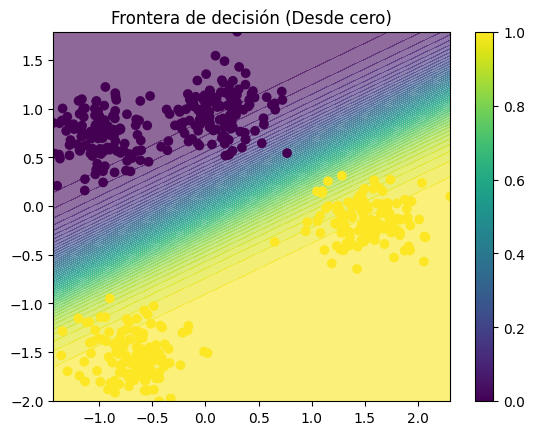

In [6]:
# Grid
x1_vals = np.linspace(X[:,1].min(), X[:,1].max(), 100)
x2_vals = np.linspace(X[:,2].min(), X[:,2].max(), 100)
xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

grid = np.c_[np.ones(xx1.ravel().shape),
             xx1.ravel(),
             xx2.ravel()]

Z = sigmoid(grid @ theta)
Z = Z.reshape(xx1.shape)

plt.figure()
plt.contourf(xx1, xx2, Z, levels=50, alpha=0.6)
plt.scatter(X[:,1], X[:,2], c=y.ravel())
plt.title("Frontera de decisión (Desde cero)")
plt.colorbar()
plt.show()


## Gráfica de entropía cruzada

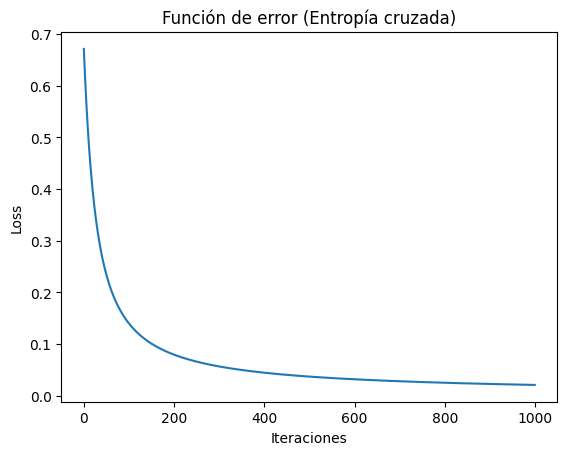

In [7]:
plt.figure()
plt.plot(loss_history)
plt.title("Función de error (Entropía cruzada)")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.show()


# SCIKIT LEARN

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

# Volver a cargar datos sin bias manual
data = pd.read_csv("Tarea_RegresionLogistica.csv")
X = data[["X1", "X2"]].values
y = data["y"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

y_pred_skl = model.predict(X_scaled)

cm_skl = confusion_matrix(y, y_pred_skl)
print("Matriz de confusión (sklearn):")
print(cm_skl)


Matriz de confusión (sklearn):
[[250   0]
 [  0 250]]


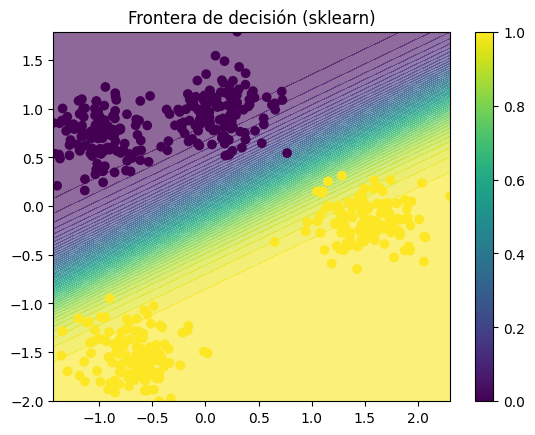

In [9]:
#Contourf 
x1_vals = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
x2_vals = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

grid = np.c_[xx1.ravel(), xx2.ravel()]
Z = model.predict_proba(grid)[:,1]
Z = Z.reshape(xx1.shape)

plt.figure()
plt.contourf(xx1, xx2, Z, levels=50, alpha=0.6)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y)
plt.title("Frontera de decisión (sklearn)")
plt.colorbar()
plt.show()
